# ROMP Milestone 1 — probabilistic depth

This notebook demonstrates the four Milestone-1 additions from
`docs/DESIGN_metrics_extension.md`:

1. **Censored / mixed CRPS** — proper scoring rule for onset outcomes that
   mix a "no-onset" atom with a continuous day-of-year distribution.
2. **FSS** — Fractions Skill Score at multiple thresholds and neighborhood
   sizes.
3. **Centroid displacement + area bias** — geographic shift of the onset
   region.
4. **CORP reliability** — MCB–DSC–UNC decomposition (the **§7 Milestone 1
   success-criterion artifact**).

Data used here is a synthetic onset field with an Indian-subcontinent-style
latitudinal gradient. The same API calls accept real onset-DOY fields
produced by the ROMP onset-detection pipeline (see
`package_run_guidance_et.ipynb`).


In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from momp.metrics.crps import censored_crps, censored_crps_field
from momp.metrics.neighborhood import fss
from momp.metrics.displacement import centroid_displacement, displacement_bias_sweep
from momp.graphics.corp_reliability import corp_decompose_brier

rng = np.random.default_rng(2026)


## Synthetic onset fields

We build a forecast and observation pair on a 40×40 grid over the Indian
subcontinent. Onset advances northward as day-of-year increases.


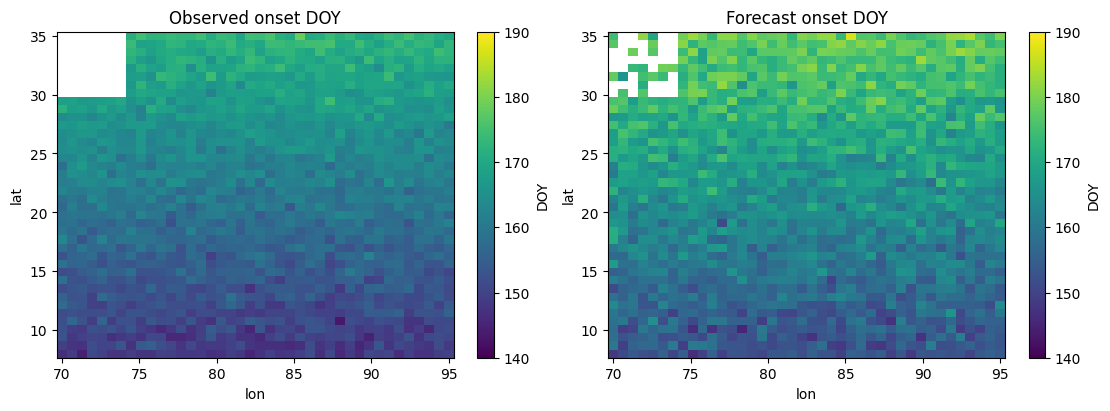

In [2]:
lats = np.linspace(8.0, 35.0, 40)
lons = np.linspace(70.0, 95.0, 40)
LAT, LON = np.meshgrid(lats, lons, indexing="ij")

# "Truth": onset advances from south to north. ~day 150 at 10N, ~day 175 at 30N.
obs_doy = 150.0 + 0.9 * (LAT - 10.0) + 2.0 * rng.standard_normal(LAT.shape)
# Forecast: unbiased pattern but with a 5-day cold bias and a northward shift.
fcst_doy = obs_doy + 5.0 + 0.5 * (LAT - 20.0) * 0.1 + 2.5 * rng.standard_normal(LAT.shape)

# Sprinkle a handful of "no onset" cells in a dry northwest corner.
no_onset = (LAT > 30) & (LON < 74)
obs_doy[no_onset] = np.nan
fcst_doy[no_onset & (rng.random(LAT.shape) < 0.7)] = np.nan

obs = xr.DataArray(obs_doy, coords={"lat": lats, "lon": lons}, dims=("lat", "lon"))
fcst = xr.DataArray(fcst_doy, coords={"lat": lats, "lon": lons}, dims=("lat", "lon"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for ax, da, title in zip(axes, [obs, fcst], ["Observed onset DOY", "Forecast onset DOY"]):
    im = ax.pcolormesh(lons, lats, da.values, cmap="viridis", vmin=140, vmax=190)
    ax.set_title(title); ax.set_xlabel("lon"); ax.set_ylabel("lat")
    fig.colorbar(im, ax=ax, label="DOY")
plt.show()


## 1. Censored / mixed CRPS

A 20-member ensemble forecast. Members disagree about both *whether* and
*when* onset occurs — exactly the mixed distribution censored CRPS was
designed for.


Mean censored CRPS over the domain: 4.615 days
Cells with CRPS > 10 days        : 41
Censored CRPS NaN count           : 0


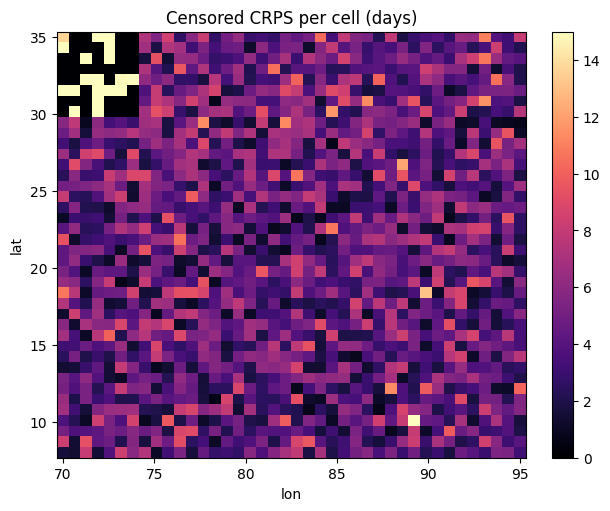

In [3]:
n_members = 20
ensemble = np.broadcast_to(fcst_doy, (n_members,) + fcst_doy.shape).copy()
ensemble += 3.0 * rng.standard_normal(ensemble.shape)
# 10% of member/cell entries: no onset.
ensemble[rng.random(ensemble.shape) < 0.10] = np.nan

ens = xr.DataArray(
    ensemble,
    dims=("member", "lat", "lon"),
    coords={"member": np.arange(n_members), "lat": lats, "lon": lons},
)

crps = censored_crps_field(ens, obs, season_end=200)
print(f"Mean censored CRPS over the domain: {float(crps.mean()):.3f} days")
print(f"Cells with CRPS > 10 days        : {int((crps > 10).sum())}")
print(f"Censored CRPS NaN count           : {int(np.isnan(crps.values).sum())}")

fig, ax = plt.subplots(1, 1, figsize=(6, 5), constrained_layout=True)
im = ax.pcolormesh(lons, lats, crps.values, cmap="magma", vmin=0, vmax=15)
ax.set_title("Censored CRPS per cell (days)")
ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.colorbar(im, ax=ax); plt.show()


## 2. FSS sweep

FSS asks whether the forecast gets the *pattern* of "onset-by-day-τ" right
at a range of spatial scales.


<xarray.DataArray 'fss' (threshold: 3, neighborhood: 6)> Size: 144B
array([[0.6116208 , 0.7278073 , 0.73421548, 0.73181474, 0.7295558 ,
        0.72671734],
       [0.82740308, 0.89990118, 0.90643143, 0.90902933, 0.91172557,
        0.91446569],
       [0.93246037, 0.96534111, 0.9705609 , 0.97403206, 0.97678975,
        0.9791964 ]])
Coordinates:
  * threshold     (threshold) float64 24B 155.0 165.0 175.0
  * neighborhood  (neighborhood) int64 48B 1 3 5 7 9 11
Attributes:
    description:  Fractions Skill Score. Roberts & Lean 2008. 1 = perfect, 0 ...


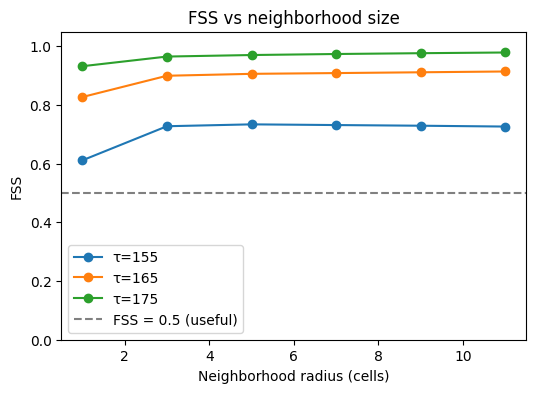

In [4]:
fss_da = fss(
    fcst, obs,
    thresholds=[155, 165, 175],
    neighborhoods=[1, 3, 5, 7, 9, 11],
)
print(fss_da)

fig, ax = plt.subplots(figsize=(6, 4))
for t in fss_da["threshold"].values:
    ax.plot(fss_da["neighborhood"], fss_da.sel(threshold=t), marker="o", label=f"τ={int(t)}")
ax.axhline(0.5, color="gray", linestyle="--", label="FSS = 0.5 (useful)")
ax.set_xlabel("Neighborhood radius (cells)"); ax.set_ylabel("FSS")
ax.set_title("FSS vs neighborhood size"); ax.legend(); ax.set_ylim(0, 1.05)
plt.show()


## 3. Centroid displacement + area bias

Which way is the forecast shifted, and by how much? Sweep over onset-date
thresholds.


           delta_lat_deg  delta_lon_deg  great_circle_km  area_bias_fraction
threshold                                                                   
155.0          -1.448004       0.953306       191.670991           -0.553830
160.0          -2.161832       0.028709       240.405109           -0.398150
165.0          -2.342294       0.107629       260.705597           -0.278210
170.0          -2.372272      -0.081476       263.925031           -0.210932
175.0          -1.348478      -0.212683       151.582298           -0.107108
180.0          -0.124119      -0.155918        21.302364           -0.008616


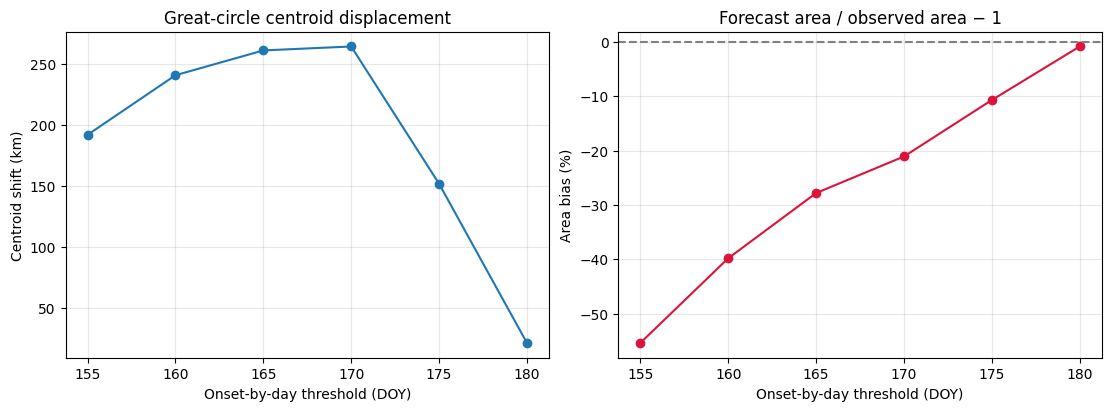

In [5]:
ds_disp = displacement_bias_sweep(fcst, obs, thresholds=[155, 160, 165, 170, 175, 180])
print(ds_disp[["delta_lat_deg", "delta_lon_deg", "great_circle_km", "area_bias_fraction"]].to_dataframe())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].plot(ds_disp["threshold"], ds_disp["great_circle_km"], marker="o")
axes[0].set_xlabel("Onset-by-day threshold (DOY)"); axes[0].set_ylabel("Centroid shift (km)")
axes[0].set_title("Great-circle centroid displacement")
axes[0].grid(alpha=0.3)

axes[1].plot(ds_disp["threshold"], 100 * ds_disp["area_bias_fraction"], marker="o", color="crimson")
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set_xlabel("Onset-by-day threshold (DOY)"); axes[1].set_ylabel("Area bias (%)")
axes[1].set_title("Forecast area / observed area − 1"); axes[1].grid(alpha=0.3)
plt.show()


## 4. CORP reliability — MCB–DSC–UNC decomposition (§7 artifact)

The key Milestone-1 success criterion: show the MCB–DSC–UNC decomposition
on a probabilistic "onset-by-day-τ" forecast. We build one from the
ensemble defined above.


In [6]:
tau = 170
# Forecast probability: fraction of ensemble members with onset ≤ τ.
member_masks = np.where(
    np.isnan(ensemble) | (ensemble > 200),
    0.0,
    (ensemble <= tau).astype(float),
)
fcst_prob = member_masks.mean(axis=0).ravel()
obs_binary = np.where(np.isfinite(obs_doy) & (obs_doy <= tau), 1.0, 0.0).ravel()

decomp = corp_decompose_brier(fcst_prob, obs_binary)
print("CORP Brier-score decomposition")
print("  Mean score (Brier) :", f"{decomp.mean_score:.4f}")
print("  MCB  (miscalib.)   :", f"{decomp.mcb:.4f}")
print("  DSC  (discrim.)    :", f"{decomp.dsc:.4f}")
print("  UNC  (climate.)    :", f"{decomp.unc:.4f}")
print("  Identity residual  :", f"{decomp.score_check - decomp.mean_score:+.2e}")


CORP Brier-score decomposition
  Mean score (Brier) : 0.1705
  MCB  (miscalib.)   : 0.1180
  DSC  (discrim.)    : 0.0550
  UNC  (climate.)    : 0.1075
  Identity residual  : +2.78e-17


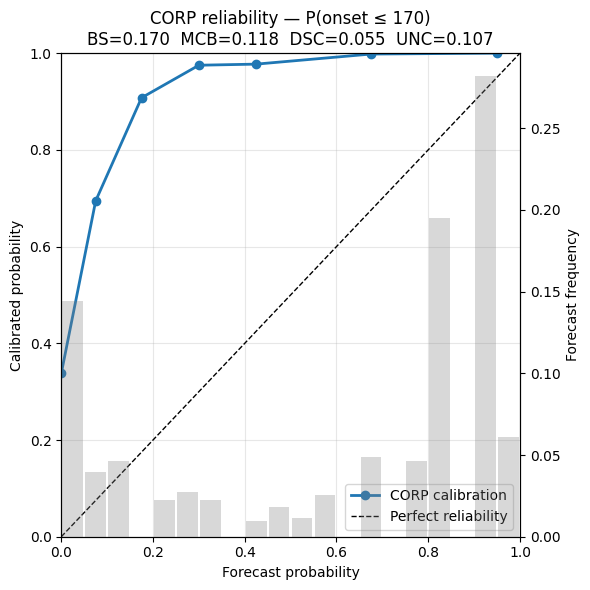

In [7]:
# Plot the CORP calibration curve and frequency histogram.
from momp.graphics.corp_reliability import _consolidate_curve
f_rep, c_rep = _consolidate_curve(decomp.forecast_prob, decomp.calibrated_y)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(f_rep, c_rep, "o-", color="tab:blue", linewidth=2, label="CORP calibration")
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect reliability")

ax2 = ax.twinx()
hist_bins = np.linspace(0, 1, 21)
counts, _ = np.histogram(decomp.forecast_prob, bins=hist_bins)
ax2.bar(0.5 * (hist_bins[:-1] + hist_bins[1:]), counts / counts.sum(),
        width=0.045, alpha=0.3, color="gray")
ax2.set_ylabel("Forecast frequency")

ax.set_xlabel("Forecast probability"); ax.set_ylabel("Calibrated probability")
ax.set_title(f"CORP reliability — P(onset ≤ {tau})\n"
             f"BS={decomp.mean_score:.3f}  MCB={decomp.mcb:.3f}  "
             f"DSC={decomp.dsc:.3f}  UNC={decomp.unc:.3f}")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.grid(alpha=0.3); ax.legend(loc="lower right")
plt.tight_layout(); plt.show()


### Reading the numbers

- **BS = MCB − DSC + UNC** is a proper-score identity for the Brier score.
- **MCB** near 0 means the forecast probabilities are well-calibrated.
- **DSC** large (close to UNC) means the forecast successfully separates
  "onset-by-τ" from "not-onset-by-τ" cases.
- **UNC** is the Brier score of the climatological (base-rate) forecast —
  a useful upper bound against which DSC is read.

For real models, compute CORP separately per lead-time bin via the
existing `momp/stats/bins.py` machinery and compare BS and its components
across models.
